# CNN - Classification d'images

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

# Collecte de données

In [2]:
# Collecte des données
# (train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()
ds = load_dataset("arincon/llm-detect")
print("Dataset imported successfully!")
print("Keys available in the DatasetDict:", ds.keys())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Dataset imported successfully!
Keys available in the DatasetDict: dict_keys(['01', '02', '03', '04'])


In [3]:
import pandas as pd

# Liste pour stocker les DataFrames de chaque split
df_list = []

# je rassemble les split en un seul df en iterant
for key in ds.keys():
    df_list.append(ds[key].to_pandas())

# Concaténer tous les df en un seul propre !
combined_df = pd.concat(df_list, ignore_index=True)
display(combined_df.head())

,text,label,source,fold,essay_id,prompt
0,There are alot reasons to keep our the despise...,0,persuade_corpus,2,,
1,Driving smart cars that drive by themself has ...,0,persuade_corpus,4,,
2,"Dear Principal,\n\nI believe that students at ...",0,persuade_corpus,0,,
3,"Dear Principal,\n\nCommunity service should no...",0,persuade_corpus,0,,
4,My argument for the development of the driverl...,0,persuade_corpus,3,,


# Prétraitement

In [4]:
# Exploration des données
combined_df.shape
# combined_df.info

# Normalisation et nettoyage des colonnes
combined_df = combined_df.dropna()
combined_df = combined_df.drop_duplicates()

#  je garde que les deux premieres colonnes text et label
combined_df = combined_df[['text', 'label']]
# Visualisation de quelques exemples de text avec leurs label
combined_df

,text,label
0,There are alot reasons to keep our the despise...,0
1,Driving smart cars that drive by themself has ...,0
2,"Dear Principal,\n\nI believe that students at ...",0
3,"Dear Principal,\n\nCommunity service should no...",0
4,My argument for the development of the driverl...,0
...,...,...
159436,Sure thing! Here's my attempt at writing an es...,1
159439,I think our principal's idea of making us do e...,1
159440,I think it's a good idea for schools to have o...,1
159445,Students often debate whether inactivity or s...,1


# Modélisation :

### L'architecture CNN avec 3 blocs convolutifs :
Utilisation de Sequential ( pipeline )

In [14]:
vocab_size = 10000
embedding_dim = 128
max_len = 100
model = models.Sequential([
    #  transformer les mots en vecteurs
    layers.Embedding(vocab_size, embedding_dim),
    layers.LSTM(64),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid') # 0 ou 1
])


### L'architecture doit être compilée (.compile()) et affichée (.summary())

In [15]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
              metrics=['accuracy'])

# model.summary() fonctionne pas

### Entrainement du modèle avec .fit()

In [16]:
# Entraînement du modèle (fit)
# Tokenisation du texte
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<unk>")
tokenizer.fit_on_texts(combined_df['text'])

sequences = tokenizer.texts_to_sequences(combined_df['text'])

padded_sequences = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')

labels = np.array(combined_df['label'])

train_sequences, test_sequences, train_labels, test_labels = train_test_split(
    padded_sequences, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"Shape of training sequences: {train_sequences.shape}")
print(f"Shape of testing sequences: {test_sequences.shape}")
print(f"Shape of training labels: {train_labels.shape}")
print(f"Shape of testing labels: {test_labels.shape}")

history = model.fit(train_sequences, train_labels, epochs=5,  # Nombre d'époques
                    validation_data=(test_sequences, test_labels)) # Validation sur les données de test


Shape of training sequences: (51595, 100)
Shape of testing sequences: (12899, 100)
Shape of training labels: (51595,)
Shape of testing labels: (12899,)
Epoch 1/5
1613/1613 ━━━━━━━━━━━━━━━━━━━━ 145s 87ms/step - accuracy: 0.9541 - loss: 0.1320 - val_accuracy: 0.9787 - val_loss: 0.0635
Epoch 2/5
1613/1613 ━━━━━━━━━━━━━━━━━━━━ 140s 86ms/step - accuracy: 0.9816 - loss: 0.0636 - val_accuracy: 0.9695 - val_loss: 0.0805
Epoch 3/5
1613/1613 ━━━━━━━━━━━━━━━━━━━━ 142s 88ms/step - accuracy: 0.9901 - loss: 0.0342 - val_accuracy: 0.9867 - val_loss: 0.0423
Epoch 4/5
1613/1613 ━━━━━━━━━━━━━━━━━━━━ 138s 86ms/step - accuracy: 0.9930 - loss: 0.0239 - val_accuracy: 0.9852 - val_loss: 0.0654
Epoch 5/5
1613/1613 ━━━━━━━━━━━━━━━━━━━━ 141s 87ms/step - accuracy: 0.9945 - loss: 0.0185 - val_accuracy: 0.9881 - val_loss: 0.0452


# Test et évaluation

In [8]:
# Evaluation du modèle sur les données de test
test_loss, test_acc = model.evaluate(test_sequences, test_labels, verbose=2)
print(f" Accuracy : {test_acc:.2f}")

404/404 - 8s - 20ms/step - accuracy: 0.9846 - loss: 0.0525
 Accuracy : 0.98


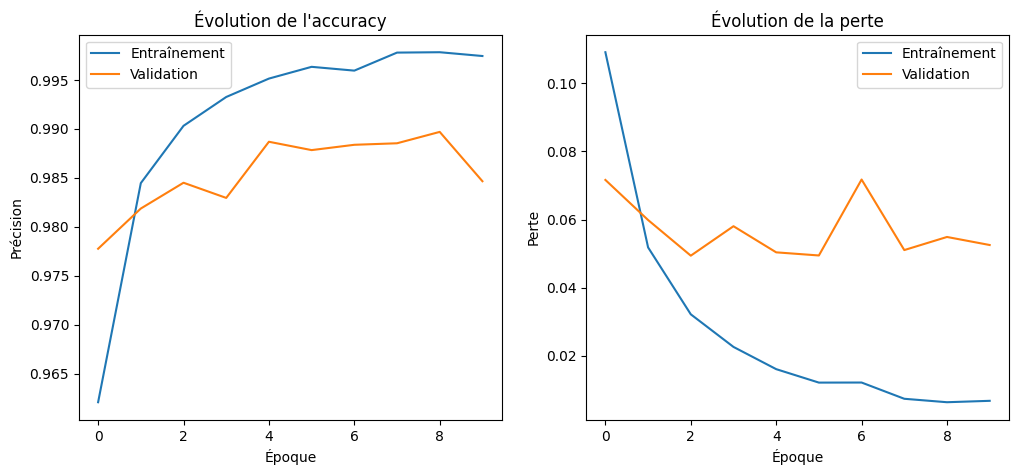

In [9]:
# Quelques graphiques des métriques d'évaluation
plt.figure(figsize=(12,5))

# Précision
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entraînement')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.xlabel('Époque')
plt.ylabel('Précision')
plt.legend()
plt.title("Évolution de l'accuracy")

# Perte
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entraînement')
plt.plot(history.history['val_loss'], label='Validation')
plt.xlabel('Époque')
plt.ylabel('Perte')
plt.legend()
plt.title("Évolution de la perte")

plt.show()




## Test

In [18]:
# Prédiction sur les données de test
# For binary classification with sigmoid output, the model directly outputs probabilities.
# Adding a Softmax layer on a single output neuron is not appropriate and will always return 1.
predictions = model.predict(test_sequences)



user_input_text = "Hello rust is cool"

user_sequence = tokenizer.texts_to_sequences([user_input_text])
user_padded_sequence = pad_sequences(user_sequence, maxlen=max_len, padding='post', truncating='post')
user_prediction = model.predict(user_padded_sequence)

predicted_prob_user = user_prediction[0][0]
predicted_label_user = 1 if predicted_prob_user >= 0.5 else 0


class_names = ['Hum', 'AI']

print(f"Votre texte: '{user_input_text}'")
# print(f"Probabilité prédite: {predicted_prob_user:.4f}")
print(f"Catégorie prédite: {class_names[predicted_label_user]}")


404/404 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Votre texte: 'Hello rust is cool'
Probabilité prédite: 0.4046
Catégorie prédite: Hum


# Evaluation avec un classification_report

In [12]:
# from sklearn.metrics import classification_report # bon outil de mesure des performances de la classification

# # Define class names for text classification (assuming 0=Human-written, 1=AI-written)
# class_names = ['Human-written', 'AI-written']

# # Convert predictions (probabilities) to predicted labels by applying a threshold of 0.5
# y_pred = (predictions >= 0.5).astype(int).flatten()

# # The true labels are already in a 1D format
# y_true = test_labels

# report = classification_report(y_true, y_pred, target_names=class_names)
# print("Rapport de classification :\n")
# print(report)


Rapport de classification :

               precision    recall  f1-score   support

Human-written       0.99      0.98      0.98      6508
   AI-written       0.98      0.99      0.98      6391

     accuracy                           0.98     12899
    macro avg       0.98      0.98      0.98     12899
 weighted avg       0.98      0.98      0.98     12899



# Bonus : sauvegarde du modèle

In [13]:
# Enregistrement du modèle : du modèle complet (architecture + poids + compile info)
model.save('LSTM2.h5')
# Sauvegarde  # Format HDF5
print("Modèle sauvegardé sous 'LSTM.h5'")

Modèle sauvegardé sous 'LSTM.h5'
